In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv('https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


EDA

fuel_efficiency_mpg don´t have a long tail

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

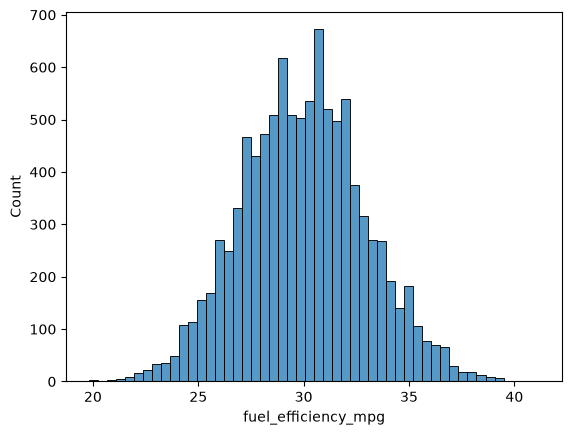

In [5]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

Q1

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Q2

In [7]:
df.horsepower.median()

np.float64(254.0)

PREPARE AND SPLIT DE DATASET

In [8]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [9]:
y_train=df_train['fuel_efficiency_mpg'].values
y_test=df_test['fuel_efficiency_mpg'].values
y_val=df_val['fuel_efficiency_mpg'].values

Q3

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [11]:
def prepare_X(df,v):
    df_num = df[['engine_displacement','horsepower','vehicle_weight','model_year']]
    df_num = df_num.fillna(v)
    X = df_num.values
    return X

OPTION WITH 0

In [12]:
X_train=prepare_X(df_train,0)
X_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [13]:
w0,w=train_linear_regression(X_train,y_train)

In [14]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [15]:
X_val = prepare_X(df_val,0)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),3)

np.float64(2.205)

OPTION WITH MEAN

In [16]:
mean=df_train.horsepower.mean()
X_train=prepare_X(df_train,mean)
w0,w=train_linear_regression(X_train,y_train)

In [17]:
X_val = prepare_X(df_val,mean)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred),3)

np.float64(2.202)

Both are equally good

Q4

In [18]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [19]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train,0)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X(df_val,0)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, round(score,4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


Q5

In [20]:

rmse_v=[]
for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    y_train=df_train['fuel_efficiency_mpg'].values
    y_test=df_test['fuel_efficiency_mpg'].values
    y_val=df_val['fuel_efficiency_mpg'].values
    X_train=prepare_X(df_train,0)
    w0,w=train_linear_regression(X_train,y_train)
    y_pred = w0 + X_train.dot(w)
    X_val = prepare_X(df_val,0)
    y_pred = w0 + X_val.dot(w)
    r=rmse(y_val, y_pred)
    rmse_v.append(r)
    

In [21]:
round(np.std(rmse_v),3)


np.float64(0.029)

Q6

In [22]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
y_train=df_train['fuel_efficiency_mpg'].values
y_test=df_test['fuel_efficiency_mpg'].values
y_val=df_val['fuel_efficiency_mpg'].values

df_full_train = pd.concat([df_train, df_val])
X_full_train = prepare_X(df_full_train,0)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, 0.001)
X_test = prepare_X(df_test,0)
y_pred = w0 + X_test.dot(w)
print(round(rmse(y_test, y_pred),3))


2.236
